# 5.3.2 固定未知量的高斯更新

## 学习目标与先修知识

能通过平方配方推导高斯均值与方差（variance）更新，解释精度相加、先验（prior）敏感性和独立性；区分知识更新与状态（state）演化。

先修：上一节的 Bayes；高斯密度、平方展开、均值和方差。 [复习上一节](01-由条件概率推导贝叶斯更新.ipynb)。

In [ ]:
from systems_science.local_service import notebook_service_ready
notebook_service_ready()

## 具体问题

一个传感器的固定偏差 θ 未知。用两次精度不同的校准测量，应该相信哪个读数更多？重复观测（observation）能在多大程度上减弱先验差异？

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from systems_science import plot_style, show_table
plot_style()
BLUE, PINK, GREEN, GRAY = '#008bfb', '#ff0051', '#009e73', '#555555'

## 初步实验

In [2]:
m=0.;P=1.
rows=[(0,m,P)]
for i,y in enumerate([1.,1.],1):
    K=P/(P+1);m=m+K*(y-m);P=P/(P+1);rows.append((i,m,P))
display(Markdown(show_table(['已用观测数','均值 / U','方差 / U²'],rows)))

| 已用观测数 | 均值 / U | 方差 / U² |
| --- | --- | --- |
| 0 | 0 | 1 |
| 1 | 0.5 | 0.5 |
| 2 | 0.666667 | 0.333333 |

## 模型假设

θ 在整个实验中固定，先验 N(m,P)、P>0；给定 θ 后 yᵢ=θ+vᵢ，vᵢ 相互独立高斯，已知方差 Rᵢ>0，且与 θ 独立。本节不加入状态转移和过程噪声（process noise）。对照先验均值 0、2 U，方差都为 1 U²；观测固定为 [1,1,0.8,1.2] U、方差 [1,1,0.25,0.25] U²。

## 数学解释与推导

后验（posterior）正比于先验密度乘似然（likelihood）密度。去掉与 θ 无关的常数，指数中的二次式为
$$-\frac12\left[\frac{(\theta-m)^2}{P}+\frac{(y-\theta)^2}{R}\right].$$
展开并按 θ 的幂收集：二次项系数 1/P+1/R，一次项系数 −2(m/P+y/R)。配成 $(\theta-m')^2/P'$ 后有
$$P'=\left(1/P+1/R\right)^{-1},\qquad m'=P'(m/P+y/R).$$
令 K=P/(P+R)，等价写成 m'=m+K(y−m)、P'=PR/(P+R)。K 无单位；R 越小观测权重越大。精度是方差倒数，独立信息使精度相加，不是使标准差（standard deviation）倒数相加。

多次条件独立（conditional independence）观测给出 $1/P_N=1/P_0+\sum_i1/R_i$，$m_N=P_N(m_0/P_0+\sum_i y_i/R_i)$。终点在精确算术中与顺序无关，但观测及其方差必须成对重排。空观测返回先验。

若两先验方差相同，最终均值差为 $(P_N/P_0)$ 倍初始均值差，说明独立信息增多可减弱先验敏感性；模型（model）错误仍会导致过度自信。μ±1.96√P 表示本高斯后验下约 95% 的概率（probability）范围，属于可信区间（credible interval），不自动具有任何模型下的频率覆盖。读数复制或共同偏移会破坏这里的独立精度相加。

## 核心实现

把公式中的量和顺序写成可检查的计算。

In [3]:
def normal_updates(prior_mean, prior_variance, observations, noise_variances):
    means, variances = [prior_mean], [prior_variance]
    for y,r in zip(observations,noise_variances):
        p = variances[-1]
        gain = p/(p+r)
        means.append(means[-1]+gain*(y-means[-1]))
        variances.append(p*r/(p+r))
    return means, variances


def compare_priors(prior_means, prior_variances, observations, noise_variances):
    results = [normal_updates(m,p,observations,noise_variances) for m,p in zip(prior_means,prior_variances)]
    means = [v[0][-1] for v in results]
    variances = [v[1][-1] for v in results]
    return means, variances, max(means)-min(means)

## 对照实验

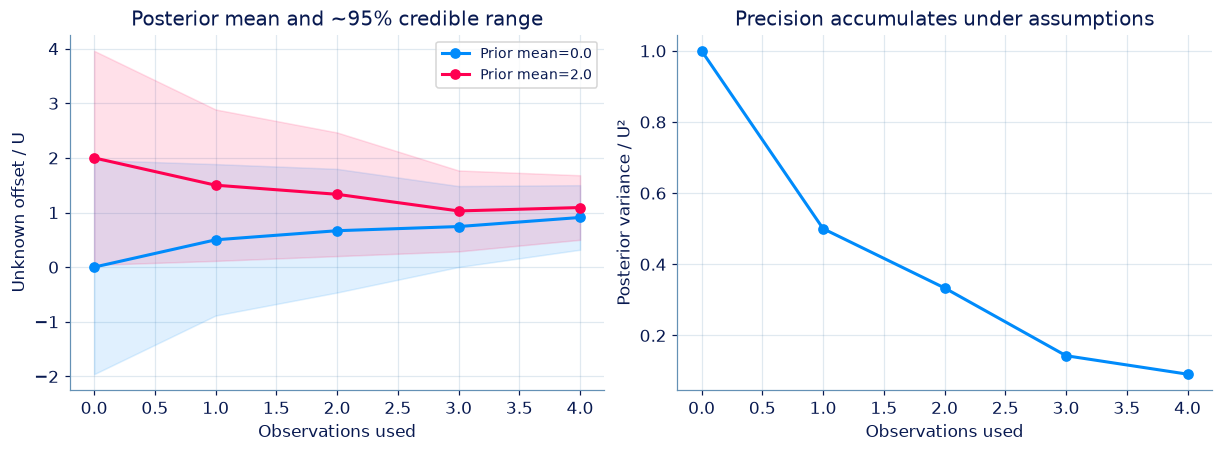

| 先验均值 / U | 末均值 / U | 末方差 / U² |
| --- | --- | --- |
| 0 | 0.909091 | 0.0909091 |
| 2 | 1.09091 | 0.0909091 |

末均值极差 / U： 0.18181818181818177


In [4]:
ys=[1.,1.,.8,1.2];rs=[1.,1.,.25,.25]
fig,axes=plt.subplots(1,2,figsize=(11,4));index=np.arange(len(ys)+1)
for m0,color in [(0.,BLUE),(2.,PINK)]:
    means,variances=normal_updates(m0,1.,ys,rs);width=1.96*np.sqrt(variances)
    axes[0].plot(index,means,'o-',color=color,label=f'Prior mean={m0}')
    axes[0].fill_between(index,np.array(means)-width,np.array(means)+width,color=color,alpha=.12)
axes[0].set(xlabel='Observations used',ylabel='Unknown offset / U',title='Posterior mean and ~95% credible range');axes[0].legend(fontsize=9)
axes[1].plot(index,normal_updates(0,1,ys,rs)[1],'o-',color=BLUE)
axes[1].set(xlabel='Observations used',ylabel='Posterior variance / U²',title='Precision accumulates under assumptions')
plt.show()
final_means,final_variances,spread=compare_priors([0,2],[1,1],ys,rs)
display(Markdown(show_table(['先验均值 / U','末均值 / U','末方差 / U²'],zip([0,2],final_means,final_variances))))
print('末均值极差 / U：',spread)

## 结果解释

均值逐次接近当前证据支持的位置，方差按信息精度缩小；这描述我们对固定 θ 的不确定性，θ 本身没有随每次更新跳动。图中的带按给定高斯模型解析计算，没有拿几次随机重复冒充参数（parameter）区间。

### 独立核对

顺序更新对照一次收集所有二次系数的批量式；避免只把同一更新写法运行两遍。

In [5]:
means,variances=normal_updates(0,1,ys,rs)
batch_variance=1/(1+sum(1/r for r in rs));batch_mean=batch_variance*sum(y/r for y,r in zip(ys,rs))
np.testing.assert_allclose([means[-1],variances[-1]],[batch_mean,batch_variance])
rev=normal_updates(0,1,ys[::-1],rs[::-1])
np.testing.assert_allclose([rev[0][-1],rev[1][-1]],[batch_mean,batch_variance])
assert normal_updates(2,.5,[],[])==([2],[.5])
assert math.isclose(spread,2*batch_variance)
assert all(0<q<=p for p,q in zip(variances,variances[1:]))
print('批量平方配方、成对逆序、空观测与先验差异系数一致。')

批量平方配方、成对逆序、空观测与先验差异系数一致。


[观察本章的动态可视化](http://127.0.0.1:8000/chapters/05-03-条件概率与贝叶斯更新/explore/)：改变一个条件，比较实现、分布（distribution）与理论参照，再返回完整推导。

## 练习与参考资料

先独立作答，再提交核对。

### 第 1 题 · Python 计算题：更新固定偏差的均值与方差

固定未知 θ 有高斯先验（prior）；yᵢ=θ+vᵢ，给定 θ 后各误差独立、零均值高斯，方差（variance）已知。逐次更新 θ 的分布（distribution），不加入状态（state）预测。

**函数与代码模板**

```python
def solve(
    prior_mean: float,
    prior_variance: float,
    observations: list[float],
    noise_variances: list[float],
) -> tuple[list[float], list[float]]:
    # 依据题目规则计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `prior_mean` | `float` | 固定未知偏差的先验均值。 | U |
| `prior_variance` | `float` | 先验方差，必须为正。 | U² |
| `observations` | `list[float]` | 依次获得的测量值。 | U |
| `noise_variances` | `list[float]` | 与观测（observation）一一对应的正噪声方差。 | U² |

**返回值**

按以下顺序返回元组：(means, variances)。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `means` | `list[float]` | 先验及每次更新后的均值。 | U |
| `variances` | `list[float]` | 先验及每次更新后的方差。 | U² |

**计算规则**

每个观测 y、方差 R：K=P/(P+R)，m←m+K(y−m)，P←P*R/(P+R)。结果包含先验；空观测返回仅含先验的两个列表。

**约束与边界**

- 所有数值有限；不修改输入（input）列表。
- |prior_mean|,|observations[i]|≤100；0.001≤prior_variance,noise_variances[i]≤100；两个观测列表等长，长度 0—30。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| prior_mean | 固定未知偏差的先验均值。 | 0 | U |
| prior_variance | 先验方差，必须为正。 | 1 | U² |
| observations | 依次获得的测量值。 | [1, 1] | U |
| noise_variances | 与观测（observation）一一对应的正噪声方差。 | [1, 1] | U² |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
prior_mean = 0
prior_variance = 1
observations = [1, 1]
noise_variances = [1, 1]

result = solve(prior_mean, prior_variance, observations, noise_variances)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| means | 先验及每次更新后的均值。 | [0, 0.5, 0.6666666666666666] | U |
| variances | 先验及每次更新后的方差。 | [1, 0.5, 0.3333333333333333] | U² |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = ([0, 0.5, 0.6666666666666666],
                   [1, 0.5, 0.3333333333333333])
```

**样例解释**

均值 [0,0.5,2/3] U，方差 [1,0.5,1/3] U²；新观测精度与已有精度相加。

允许 Python 标准库；绝对误差 1e-09 或相对误差 1e-08。

[作答：更新固定偏差的均值与方差](http://127.0.0.1:8000/chapters/05-03-%E6%9D%A1%E4%BB%B6%E6%A6%82%E7%8E%87%E4%B8%8E%E8%B4%9D%E5%8F%B6%E6%96%AF%E6%9B%B4%E6%96%B0/practice/?question=p05-normal-update)

### 第 2 题 · Python 计算题：有限观测后还剩多少先验差异

对同一固定未知偏差，采用不同的高斯先验（prior），但用相同独立观测（observation）更新。返回各方案的最终均值、方差（variance），以及最终均值的极差。

**函数与代码模板**

```python
def solve(
    prior_means: list[float],
    prior_variances: list[float],
    observations: list[float],
    noise_variances: list[float],
) -> tuple[list[float], list[float], float]:
    # 依据题目规则计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `prior_means` | `list[float]` | 各方案先验均值。 | U |
| `prior_variances` | `list[float]` | 各方案正先验方差。 | U² |
| `observations` | `list[float]` | 依次获得的测量值。 | U |
| `noise_variances` | `list[float]` | 与观测一一对应的正噪声方差。 | U² |

**返回值**

按以下顺序返回元组：(final_means, final_variances, mean_range)。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `final_means` | `list[float]` | 各方案最终均值。 | U |
| `final_variances` | `list[float]` | 各方案最终方差。 | U² |
| `mean_range` | `float` | 最终均值最大值减最小值。 | U |

**计算规则**

每个观测 y、方差 R：K=P/(P+R)，m←m+K(y−m)，P←P*R/(P+R)。结果包含先验；空观测返回仅含先验的两个列表。分别更新所有方案；这里只返回末值。极差不是置信区间（confidence interval）。

**约束与边界**

- 所有数值有限；不修改输入（input）列表。
- 先验列表等长，长度 1—10；|均值及观测|≤100；所有方差在 [0.001,100]；观测与误差方差列表等长，长度 0—30。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| prior_means | 各方案先验均值。 | [0, 2] | U |
| prior_variances | 各方案正先验方差。 | [1, 1] | U² |
| observations | 依次获得的测量值。 | [1] | U |
| noise_variances | 与观测一一对应的正噪声方差。 | [1] | U² |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
prior_means = [0, 2]
prior_variances = [1, 1]
observations = [1]
noise_variances = [1]

result = solve(prior_means, prior_variances, observations, noise_variances)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| final_means | 各方案最终均值。 | [0.5, 1.5] | U |
| final_variances | 各方案最终方差。 | [0.5, 0.5] | U² |
| mean_range | 最终均值最大值减最小值。 | 1 | U |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = ([0.5, 1.5], [0.5, 0.5], 1.0)
```

**样例解释**

两方案最终均值为 [0.5,1.5]，方差均为 0.5，均值极差为 1 U；一次观测还没有消除先验差异。

允许 Python 标准库；绝对误差 1e-09 或相对误差 1e-08。

[作答：有限观测后还剩多少先验差异](http://127.0.0.1:8000/chapters/05-03-%E6%9D%A1%E4%BB%B6%E6%A6%82%E7%8E%87%E4%B8%8E%E8%B4%9D%E5%8F%B6%E6%96%AF%E6%9B%B4%E6%96%B0/practice/?question=p05-prior-sensitivity)

### 第 3 题 · 多项选择题：哪一个读数权重更大

高斯更新先验（prior）方差（variance） P=1 U²，同一观测（observation）值分别配 R=0.1 或 R=10 U²。哪些正确？

- **A.** R=0.1 时 K 更大。
- **B.** R=10 时观测更精确。
- **C.** 较小 R 给出较小后验（posterior）方差。
- **D.** 方差缩小本身证明模型（model）正确。

[作答：哪一个读数权重更大](http://127.0.0.1:8000/chapters/05-03-%E6%9D%A1%E4%BB%B6%E6%A6%82%E7%8E%87%E4%B8%8E%E8%B4%9D%E5%8F%B6%E6%96%AF%E6%9B%B4%E6%96%B0/practice/?question=p05-precision)

### 第 4 题 · 单项选择题：这一步是不是动态滤波

用条件高斯公式连续处理同一固定 θ 的多次测量。哪项正确？

- **A.** 它是固定未知量的更新；动态状态（state）还需明确时间演化与预测。
- **B.** 数据多了就不需要观测（observation）模型（model）。
- **C.** θ 在更新后物理上发生跳变。
- **D.** 每次必须加过程噪声（process noise），哪怕模型没有。

[作答：这一步是不是动态滤波](http://127.0.0.1:8000/chapters/05-03-%E6%9D%A1%E4%BB%B6%E6%A6%82%E7%8E%87%E4%B8%8E%E8%B4%9D%E5%8F%B6%E6%96%AF%E6%9B%B4%E6%96%B0/practice/?question=p05-fixed-quantity)

### 第 5 题 · 多项选择题：独立测量的顺序有什么影响

固定量高斯模型（model）的先验（prior）与各观测（observation）误差方差（variance）已知。观测及其方差成对重排。哪些成立？

- **A.** 只重排 y 而不重排相应 R 也总是相同。
- **B.** 每一步中间后验（posterior）必须完全相同。
- **C.** 最终精度 1/P 等于先验精度加各 1/R。
- **D.** 最终后验在精确算术中与顺序无关。

[作答：独立测量的顺序有什么影响](http://127.0.0.1:8000/chapters/05-03-%E6%9D%A1%E4%BB%B6%E6%A6%82%E7%8E%87%E4%B8%8E%E8%B4%9D%E5%8F%B6%E6%96%AF%E6%9B%B4%E6%96%B0/practice/?question=p05-order)

**进一步阅读**

[MIT 6.041 讲义](https://ocw.mit.edu/courses/6-041-probabilistic-systems-analysis-and-applied-probability-fall-2010/pages/lecture-notes/)：第 21—22 讲：Bayesian inference；正文单独完成标量高斯配方。